## EDA for the peak UMAP - a collection of exploratory workflows with half-baked ideas

- projection of the chromatin accessibilities from peak clusters onto the cell UMAP
- Hox gene cluster accessibility
- Hematopoesis cell cluster

## EDA 2: projection of the accessibility to the cell UMAP

- for the peak groups in each leiden cluster (peak UMAP), show their accessibility profiles on the cell UMAP

In [22]:
adata_peaks = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_peaks_integrated_master_filtered.h5ad")
adata_peaks

AnnData object with n_obs × n_vars = 94562 × 640834
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage'
    var: 'count', 'percentile'
    obsm: 'X_integrated_lsi', 'X_umap', 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'

In [26]:
# # First get peaks for each leiden cluster
# leiden_peaks = {}
# for cluster in peaks_pb_hvp_50k.obs['leiden_0.7'].unique():
#     # Get peaks belonging to this cluster
#     peaks_in_cluster = peaks_pb_hvp_50k[peaks_pb_hvp_50k.obs['leiden_0.7']==cluster].obs_names.tolist()
#     leiden_peaks[cluster] = peaks_in_cluster

# # Now compute average accessibility for each peak group
# peak_group_scores = pd.DataFrame(index=adata_peaks.obs_names)
# for cluster, peaks in leiden_peaks.items():
#     # Get subset of peaks matrix for this cluster's peaks
#     peaks_subset = adata_peaks[:, peaks].X
    
#     # Compute mean accessibility across these peaks
#     mean_acc = np.array(peaks_subset.mean(axis=1)).flatten()
    
#     # Add to dataframe
#     peak_group_scores[f'Cluster_{cluster}_accessibility'] = mean_acc

# # Add scores to original adata object
# for col in peak_group_scores.columns:
#     adata_peaks.obs[col] = peak_group_scores[col]

# # Plot scores on UMAP
# sc.pl.umap(adata_peaks, color=peak_group_scores.columns, ncols=3)

import scipy.sparse as sp

# First get peaks for each leiden cluster
leiden_peaks = {}
for cluster in peaks_pb_hvp_50k.obs['leiden_0.7'].unique():
    peaks_in_cluster = peaks_pb_hvp_50k[peaks_pb_hvp_50k.obs['leiden_0.7']==cluster].obs_names.tolist()
    leiden_peaks[cluster] = peaks_in_cluster

# Now compute average accessibility for each peak group
peak_group_scores = pd.DataFrame(index=adata_peaks.obs_names)
for cluster, peaks in leiden_peaks.items():
    # Get subset of peaks matrix for this cluster's peaks
    peaks_subset = adata_peaks[:, peaks].X
    
    # If matrix is sparse, keep it sparse for the mean calculation
    if sp.issparse(peaks_subset):
        mean_acc = np.array(peaks_subset.mean(axis=1)).flatten()
    else:
        mean_acc = peaks_subset.mean(axis=1)
    
    # Add to dataframe
    peak_group_scores[f'Cluster_{cluster}_accessibility'] = mean_acc

# Add scores to original adata object
for col in peak_group_scores.columns:
    adata_peaks.obs[col] = peak_group_scores[col]

# Plot scores on UMAP
sc.pl.umap(adata_peaks, color=peak_group_scores.columns, ncols=3)

MemoryError: Unable to allocate 11.1 GiB for an array with shape (1483658429,) and data type float64

## EDA3: Hox gene cluster (Hoxc)

In [16]:
peaks_pb_hvp_50k.obs["linked_gene"].str.contains("hox")

1-30119-30406           False
1-102102-102943         False
1-128797-129190         False
1-217215-217640         False
1-256849-257455         False
                        ...  
25-37374245-37375939    False
25-37441836-37444212    False
25-37457158-37457567    False
25-37471466-37471801    False
25-37500598-37500859    False
Name: linked_gene, Length: 50000, dtype: bool

In [18]:
peaks_pb_hvp_50k[peaks_pb_hvp_50k.obs["linked_gene"].str.contains("hox")]

,count,percentile,highly_variable,highly_variable_rank,means,variances,variances_norm,dispersions,dispersions_norm,chrom,...,leiden_0.5,leiden_0.3,leiden_1,optic_cup_subclust,linked_gene,link_score,link_zscore,link_pvalue,is_linked,hemato_manual
3-23676305-23678208,70574.0,0.996815,True,NaN,0.000009,25742.382701,0.844545,-12.716060,1.505205,3,...,11,4,14,unassigned,hoxb5a,0.075987,6.561222,2.668424e-11,Linked,unassigned
3-23688284-23689926,60285.0,0.995186,True,NaN,0.000008,29045.730120,0.856418,-12.591646,1.678210,3,...,11,4,14,unassigned,hoxb5a,0.082795,10.137272,1.887462e-24,Linked,unassigned
11-2187306-2188243,4246.0,0.878749,True,NaN,0.000003,2956.167547,0.660961,-11.682740,1.535391,11,...,11,4,14,unassigned,hoxc6b,0.075910,2.778063,2.734201e-03,Linked,unassigned
11-2227823-2228843,2700.0,0.817349,True,NaN,0.000002,3791.000129,1.144878,-11.766333,1.531842,11,...,12,4,8,unassigned,hoxc6b,0.061377,2.291613,1.096400e-02,Linked,unassigned
16-20894722-20895259,5388.0,0.901630,True,NaN,0.000004,3861.516135,0.659048,-11.465372,1.899915,16,...,11,4,14,unassigned,hoxa10b,0.075455,7.969819,7.945372e-16,Linked,unassigned
23-35944736-35945529,35979.0,0.986636,True,NaN,0.000006,37318.051825,0.864173,-11.808612,1.763738,23,...,11,4,14,unassigned,hoxc10a,0.102613,11.453941,1.123461e-30,Linked,unassigned
23-35986771-35987692,17618.0,0.967316,True,NaN,0.000005,24685.202886,1.017492,-11.706568,1.607284,23,...,11,4,14,unassigned,hoxc10a,0.106399,4.482127,3.695135e-06,Linked,unassigned
23-36022882-36025011,36584.0,0.986987,True,NaN,0.000008,16014.946692,0.638240,-12.424117,1.526479,23,...,11,4,14,unassigned,hoxc11a,0.070857,9.640918,2.685286e-22,Linked,unassigned
23-36058391-36059094,11456.0,0.950096,True,NaN,0.000005,12464.930316,0.803627,-11.573303,1.871044,23,...,11,4,14,unassigned,hoxc8a,0.081014,4.287762,9.024106e-06,Linked,unassigned
23-36074653-36075925,20566.0,0.972292,True,NaN,0.000007,12200.648200,0.696525,-12.104088,1.602372,23,...,11,4,14,unassigned,hoxc8a,0.083838,6.698830,1.050472e-11,Linked,unassigned


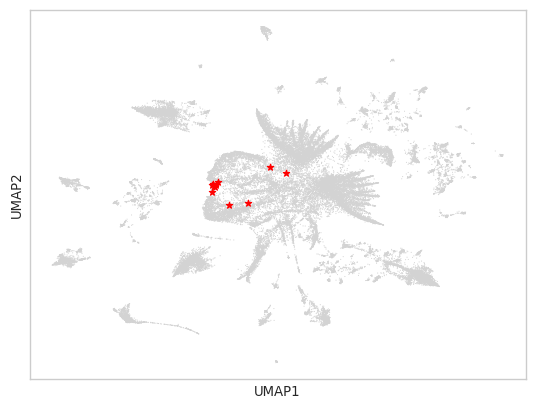

In [28]:
# Get UMAP coordinates of your subset
subset_coords = peaks_pb_hvp_50k[peaks_pb_hvp_50k.obs_names.isin(peaks_pb_hvp_50k[peaks_pb_hvp_50k.obs["linked_gene"].str.contains("hoxc")].obs_names)].obsm['X_umap']

# Plot base UMAP
sc.pl.umap(peaks_pb_hvp_50k, show=False)

# Add markers for subset
plt.scatter(subset_coords[:, 0], subset_coords[:, 1], 
           c='red', 
           # s=100, 
           marker='*')
plt.show()

In [31]:
peaks_pb_hvp_50k[peaks_pb_hvp_50k.obs_names.isin(peaks_pb_hvp_50k[peaks_pb_hvp_50k.obs["linked_gene"].str.contains("hoxc")].obs_names)].obs

,count,percentile,highly_variable,highly_variable_rank,means,variances,variances_norm,dispersions,dispersions_norm,chrom,...,leiden_0.5,leiden_0.3,leiden_1,optic_cup_subclust,linked_gene,link_score,link_zscore,link_pvalue,is_linked,hemato_manual
11-2187306-2188243,4246.0,0.878749,True,NaN,0.000003,2956.167547,0.660961,-11.682740,1.535391,11,...,11,4,14,unassigned,hoxc6b,0.075910,2.778063,2.734201e-03,Linked,unassigned
11-2227823-2228843,2700.0,0.817349,True,NaN,0.000002,3791.000129,1.144878,-11.766333,1.531842,11,...,12,4,8,unassigned,hoxc6b,0.061377,2.291613,1.096400e-02,Linked,unassigned
23-35944736-35945529,35979.0,0.986636,True,NaN,0.000006,37318.051825,0.864173,-11.808612,1.763738,23,...,11,4,14,unassigned,hoxc10a,0.102613,11.453941,1.123461e-30,Linked,unassigned
23-35986771-35987692,17618.0,0.967316,True,NaN,0.000005,24685.202886,1.017492,-11.706568,1.607284,23,...,11,4,14,unassigned,hoxc10a,0.106399,4.482127,3.695135e-06,Linked,unassigned
23-36022882-36025011,36584.0,0.986987,True,NaN,0.000008,16014.946692,0.638240,-12.424117,1.526479,23,...,11,4,14,unassigned,hoxc11a,0.070857,9.640918,2.685286e-22,Linked,unassigned
23-36058391-36059094,11456.0,0.950096,True,NaN,0.000005,12464.930316,0.803627,-11.573303,1.871044,23,...,11,4,14,unassigned,hoxc8a,0.081014,4.287762,9.024106e-06,Linked,unassigned
23-36074653-36075925,20566.0,0.972292,True,NaN,0.000007,12200.648200,0.696525,-12.104088,1.602372,23,...,11,4,14,unassigned,hoxc8a,0.083838,6.698830,1.050472e-11,Linked,unassigned
23-36078072-36079024,20475.0,0.972153,True,NaN,0.000006,19368.586006,0.786319,-11.982129,1.533712,23,...,11,4,14,unassigned,hoxc6a,0.073712,4.186471,1.416624e-05,Linked,unassigned
23-36130670-36132355,71708.0,0.996952,True,NaN,0.000009,26766.218910,0.707980,-12.883294,1.622482,23,...,11,4,14,unassigned,hoxc6a,0.051650,3.750724,8.816247e-05,Linked,unassigned
23-36133926-36134925,23051.0,0.975693,True,NaN,0.000006,17689.206872,0.823688,-11.996605,1.514522,23,...,5,5,3,unassigned,hoxc1a,0.093470,6.202260,2.782894e-10,Linked,unassigned


In [33]:
peaks_pb_hvp_50k[peaks_pb_hvp_50k.obs_names.isin(peaks_pb_hvp_50k[peaks_pb_hvp_50k.obs["linked_gene"].str.contains("hoxc")].obs_names)].obs["celltype"]

11-2187306-2188243              tail_bud
11-2227823-2228843           spinal_cord
23-35944736-35945529                NMPs
23-35986771-35987692                NMPs
23-36022882-36025011                NMPs
23-36058391-36059094                NMPs
23-36074653-36075925                NMPs
23-36078072-36079024                NMPs
23-36130670-36132355          pronephros
23-36133926-36134925             neurons
23-36193341-36193973    heart_myocardium
Name: celltype, dtype: category
Categories (6, object): ['NMPs', 'heart_myocardium', 'neurons', 'pronephros', 'spinal_cord', 'tail_bud']

In [34]:
peaks_hox = peaks_pb_hvp_50k[peaks_pb_hvp_50k.obs_names.isin(peaks_pb_hvp_50k[peaks_pb_hvp_50k.obs["linked_gene"].str.contains("hoxc")].obs_names)]
peaks_hox

View of AnnData object with n_obs × n_vars = 11 × 190
    obs: 'count', 'percentile', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'dispersions', 'dispersions_norm', 'chrom', 'peak_type', 'manual_annotation_peaks', 'leiden_r1', 'gene_body_overlaps', 'nearest_gene', 'distance_to_tss', 'distance_to_tss_binned', 'accessibility_notochord', 'accessibility_spinal_cord', 'accessibility_primordial_germ_cells', 'accessibility_NMPs', 'accessibility_neural', 'accessibility_neural_floor_plate', 'accessibility_neural_optic', 'accessibility_hatching_gland', 'accessibility_PSM', 'accessibility_neural_crest', 'accessibility_neural_telencephalon', 'accessibility_endoderm', 'accessibility_lateral_plate_mesoderm', 'accessibility_endocrine_pancreas', 'accessibility_epidermis', 'accessibility_neurons', 'accessibility_fast_muscle', 'accessibility_hemangioblasts', 'accessibility_differentiating_neurons', 'accessibility_optic_cup', 'accessibility_hindbrain', 'accessibilit

In [39]:
peaks_hox.obs[['linked_gene', 'accessibility_0somites', 'accessibility_5somites','accessibility_10somites', 
               'accessibility_15somites','accessibility_20somites', 'accessibility_30somites', 'timepoint']]

,linked_gene,accessibility_0somites,accessibility_5somites,accessibility_10somites,accessibility_15somites,accessibility_20somites,accessibility_30somites,timepoint
11-2187306-2188243,hoxc6b,22.613872,22.534990,24.068693,15.032161,24.970571,2.806525,20somites
11-2227823-2228843,hoxc6b,-5.690260,5.259162,13.954483,11.873688,18.342767,2.936512,20somites
23-35944736-35945529,hoxc10a,90.140637,88.111839,58.337268,51.644579,44.488998,20.776865,0somites
23-35986771-35987692,hoxc10a,53.848235,83.742491,66.799411,59.358178,34.261159,-4.099733,5somites
23-36022882-36025011,hoxc11a,63.438998,78.939144,84.906231,97.324448,91.650037,45.417276,15somites
23-36058391-36059094,hoxc8a,39.677636,42.577729,50.902558,48.788135,56.188454,16.841242,20somites
23-36074653-36075925,hoxc8a,66.431772,57.738858,71.589771,59.960612,68.398446,39.174635,10somites
23-36078072-36079024,hoxc6a,60.121316,61.019542,69.604698,61.376204,56.997151,18.866401,10somites
23-36130670-36132355,hoxc6a,111.904659,117.019067,93.654541,89.541734,68.932733,51.661788,5somites
23-36133926-36134925,hoxc1a,44.228106,48.637512,58.800138,52.624683,66.210651,44.862459,20somites


/tmp/ipykernel_2805653/2687307378.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  peaks_chr23.obs['start_pos'] = peaks_chr23.obs_names.str.split('-').str[1].astype(int)


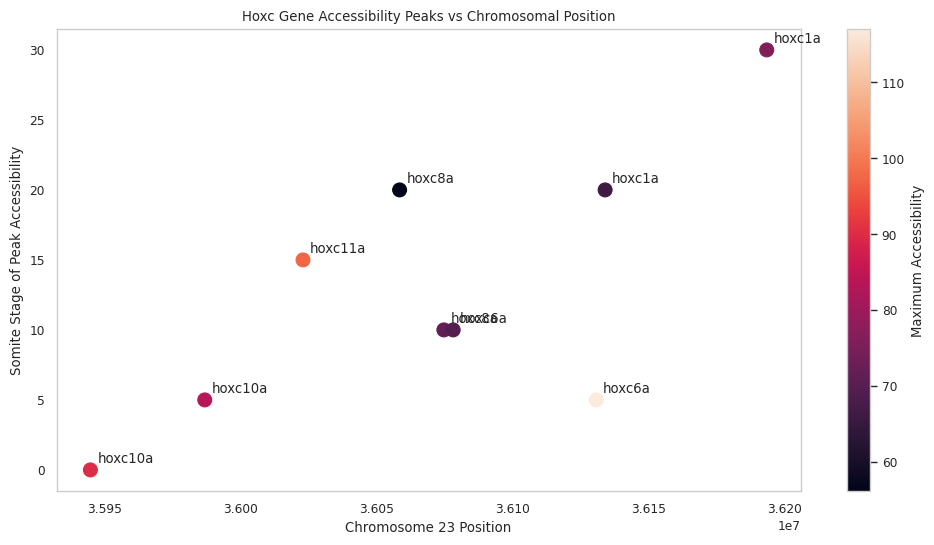

In [63]:
# First, let's parse the obs_names to get chromosome and position info
peaks_chr23 = peaks_hox[peaks_hox.obs_names.str.startswith('23-')]

# Parse start positions from obs_names
peaks_chr23.obs['start_pos'] = peaks_chr23.obs_names.str.split('-').str[1].astype(int)

# For each peak, find the somite stage with maximum accessibility
somite_cols = ['accessibility_0somites', 'accessibility_5somites', 'accessibility_10somites',
               'accessibility_15somites', 'accessibility_20somites', 'accessibility_30somites']

# Get the somite stage where accessibility peaks for each gene
peaks_chr23.obs['peak_somite'] = peaks_chr23.obs[somite_cols].idxmax(axis=1).str.replace('accessibility_', '').str.replace('somites', '')

# Create scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(peaks_chr23.obs['start_pos'], 
           peaks_chr23.obs['peak_somite'].astype(int),
           c=peaks_chr23.obs[somite_cols].max(axis=1),  # Color by max accessibility
           s=100)

# Add gene labels
for idx, row in peaks_chr23.obs.iterrows():
    plt.annotate(row['linked_gene'], 
                (row['start_pos'], int(row['peak_somite'])),
                xytext=(5, 5), textcoords='offset points')

plt.xlabel('Chromosome 23 Position')
plt.ylabel('Somite Stage of Peak Accessibility')
plt.title('Hoxc Gene Accessibility Peaks vs Chromosomal Position')
plt.colorbar(label='Maximum Accessibility')
plt.grid(False)
plt.show()

In [87]:
# First, let's parse the obs_names to get chromosome and position info
peaks_chr23 = peaks_pb_hvp_50k[peaks_pb_hvp_50k.obs_names.str.startswith('23-')]

# Parse start positions from obs_names
peaks_chr23.obs['start_pos'] = peaks_chr23.obs_names.str.split('-').str[1].astype(int)


/tmp/ipykernel_2805653/288228658.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  peaks_chr23.obs['start_pos'] = peaks_chr23.obs_names.str.split('-').str[1].astype(int)


In [100]:
peaks_chr23_transposed = peaks_chr23.T
peaks_chr23_transposed

AnnData object with n_obs × n_vars = 190 × 1644
    obs: 'annotation_ML_coarse', 'dev_stage', 'scale_factor', 'n_cells', 'mean_depth', 'mean', 'std'
    var: 'count', 'percentile', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'dispersions', 'dispersions_norm', 'chrom', 'peak_type', 'manual_annotation_peaks', 'leiden_r1', 'gene_body_overlaps', 'nearest_gene', 'distance_to_tss', 'distance_to_tss_binned', 'accessibility_notochord', 'accessibility_spinal_cord', 'accessibility_primordial_germ_cells', 'accessibility_NMPs', 'accessibility_neural', 'accessibility_neural_floor_plate', 'accessibility_neural_optic', 'accessibility_hatching_gland', 'accessibility_PSM', 'accessibility_neural_crest', 'accessibility_neural_telencephalon', 'accessibility_endoderm', 'accessibility_lateral_plate_mesoderm', 'accessibility_endocrine_pancreas', 'accessibility_epidermis', 'accessibility_neurons', 'accessibility_fast_muscle', 'accessibility_hemangioblasts', 'accessibilit

In [114]:
sc.pp.log1p(peaks_chr23_transposed, layer="normalized")
peaks_chr23_transposed

AnnData object with n_obs × n_vars = 190 × 1644
    obs: 'annotation_ML_coarse', 'dev_stage', 'scale_factor', 'n_cells', 'mean_depth', 'mean', 'std'
    var: 'count', 'percentile', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'dispersions', 'dispersions_norm', 'chrom', 'peak_type', 'manual_annotation_peaks', 'leiden_r1', 'gene_body_overlaps', 'nearest_gene', 'distance_to_tss', 'distance_to_tss_binned', 'accessibility_notochord', 'accessibility_spinal_cord', 'accessibility_primordial_germ_cells', 'accessibility_NMPs', 'accessibility_neural', 'accessibility_neural_floor_plate', 'accessibility_neural_optic', 'accessibility_hatching_gland', 'accessibility_PSM', 'accessibility_neural_crest', 'accessibility_neural_telencephalon', 'accessibility_endoderm', 'accessibility_lateral_plate_mesoderm', 'accessibility_endocrine_pancreas', 'accessibility_epidermis', 'accessibility_neurons', 'accessibility_fast_muscle', 'accessibility_hemangioblasts', 'accessibilit

In [115]:
np.sum(np.expm1(peaks_chr23.X.todense()),1)

matrix([[ 2.38506266e+04],
        [ 3.33042462e+04],
        [-2.33926845e+01],
        ...,
        [ 2.61789681e+02],
        [ 9.10135045e+05],
        [ 2.55104742e+06]])

In [117]:
peaks_chr23.X = peaks_chr23_transposed.T.X.copy()

In [84]:
# peaks_chr23.X = peaks_chr23.layers["log_norm"].copy()

In [127]:
peaks_hoxc = peaks_chr23[peaks_chr23.obs["linked_gene"].str.startswith("hoxc")]
peaks_hoxc

View of AnnData object with n_obs × n_vars = 9 × 190
    obs: 'count', 'percentile', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'dispersions', 'dispersions_norm', 'chrom', 'peak_type', 'manual_annotation_peaks', 'leiden_r1', 'gene_body_overlaps', 'nearest_gene', 'distance_to_tss', 'distance_to_tss_binned', 'accessibility_notochord', 'accessibility_spinal_cord', 'accessibility_primordial_germ_cells', 'accessibility_NMPs', 'accessibility_neural', 'accessibility_neural_floor_plate', 'accessibility_neural_optic', 'accessibility_hatching_gland', 'accessibility_PSM', 'accessibility_neural_crest', 'accessibility_neural_telencephalon', 'accessibility_endoderm', 'accessibility_lateral_plate_mesoderm', 'accessibility_endocrine_pancreas', 'accessibility_epidermis', 'accessibility_neurons', 'accessibility_fast_muscle', 'accessibility_hemangioblasts', 'accessibility_differentiating_neurons', 'accessibility_optic_cup', 'accessibility_hindbrain', 'accessibility

/tmp/ipykernel_2805653/3200845328.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  viridis = cm.get_cmap('viridis', len(stages))


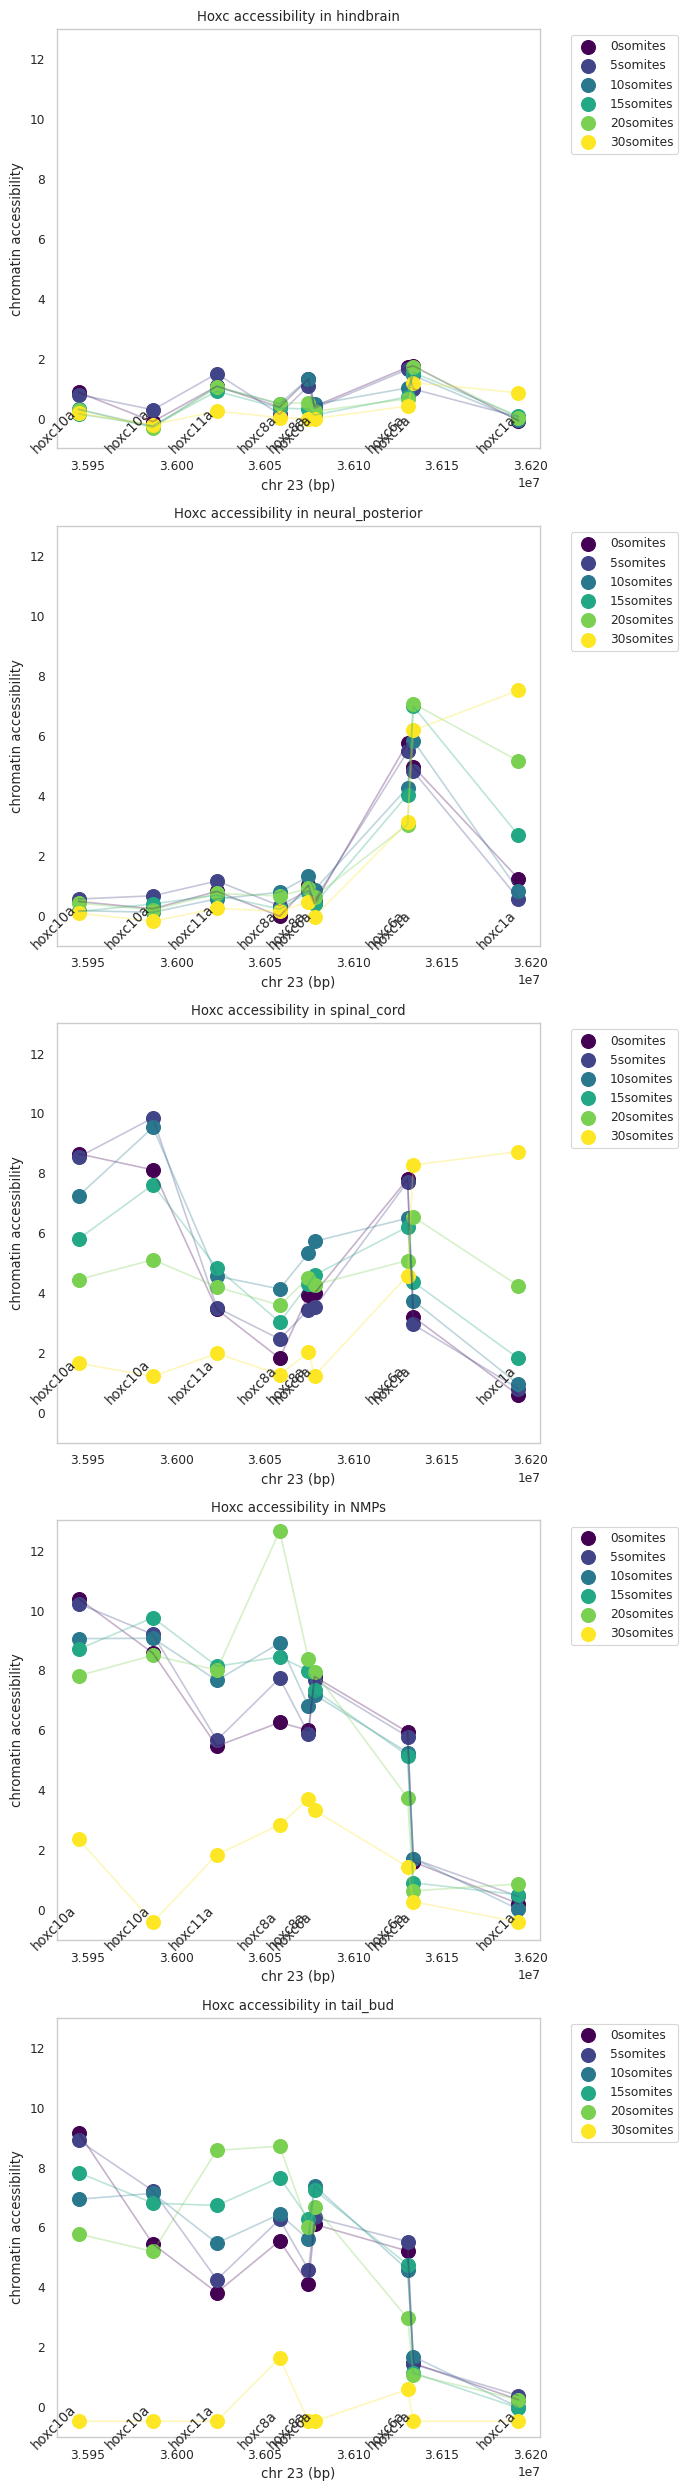

In [130]:
# Define our tissues of interest
tissues_of_interest = ['hindbrain',
    'neural_posterior', 'spinal_cord',
    'NMPs', 'tail_bud', 
]

# Define color map
import matplotlib.cm as cm
viridis = cm.get_cmap('viridis', len(stages))
# # Define color map
# viridis = plt.colormaps.get_cmap('viridis')

# Create subplots dynamically based on the number of tissues
fig, axes = plt.subplots(len(tissues_of_interest), 1, figsize=(7, 5 * len(tissues_of_interest)))
if len(tissues_of_interest) == 1:
    axes = [axes]  # Ensure axes is iterable when there is only one tissue

# Iterate through each tissue type
for ax, celltype in zip(axes, tissues_of_interest):
    for stage_idx, stage in enumerate(stages):
        var_name = f"{celltype}_{stage}"
        if var_name in peaks_hoxc.var_names:
            col_idx = peaks_hoxc.var_names.get_loc(var_name)
            accessibility = peaks_hoxc.X[:, col_idx].toarray().flatten() if hasattr(peaks_hoxc.X, 'toarray') else peaks_hoxc.X[:, col_idx]
            
            # Sort points by chromosome position to connect them properly
            positions = peaks_hoxc.obs['start_pos'].to_numpy()
            sorted_indices = np.argsort(positions)
            sorted_pos = positions[sorted_indices]
            sorted_acc = accessibility[sorted_indices]
            
            # Plot line connecting points
            ax.plot(sorted_pos, sorted_acc, '-', color=viridis(stage_idx/len(stages)), alpha=0.3)
            # Plot points on top
            ax.scatter(sorted_pos, sorted_acc,
                       c=[viridis(stage_idx/len(stages))],
                       s=100,
                       label=f'{stage}')
    
    # Add gene labels in each subplot
    for idx, row in peaks_hoxc.obs.iterrows():
        ax.annotate(row['linked_gene'], 
                    (row['start_pos'], min(accessibility)),
                    xytext=(0, -20), textcoords='offset points',
                    rotation=45, ha='right')

    ax.set_xlabel('chr 23 (bp)')
    ax.set_ylabel('chromatin accessibility')
    ax.set_title(f'Hoxc accessibility in {celltype}')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(False)
    ax.set_ylim(-1, 13)  # Set y-axis range

plt.savefig(figpath + "hoxc_chr_access_dynamics_celltypes.pdf")
plt.tight_layout()
plt.show()

## EDA4: Hematopoesis

- the hematopoetic system (hemangioblast, hematopoetic vasculature) regulatory programs are clustered together strongly based on their "celltype", less than their "timepoint". However, there's a clear pattern of "temporality" in the data - that the hemangioblast and hematopoetic vasculature shares the early timepoints, then branches out from there...

- This might be a good place to zoom-in and do a deeper dive into the biology. 